In [1]:
## Exploratory Data Analysis (EDA) ##

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import folium
from math import radians, sin, cos, sqrt, atan2
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


%matplotlib inline
# Load data
df = pd.read_csv("/home/amolla/GIS_Spring26/GIS_521_FinalProject/BRAZIL_AllVariables_Combined_with_LatLon.csv")

static_vars = [
    "near_coast_km", "elevation_meter",
    "population_density", "builtup_density",
    "latitude", "longitude"
]

monthly_var_bases = [
    "pdsi",
    "skin_temperature",
    "temperature_2m_max", "temperature_2m_min",
    "total_precipitation_sum", "vs"
]

dengue_base = "den"

months = [f"{m:02d}" for m in range(1, 13)]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# ── 1. Static variables ───────────────────────────────────────────────────────
static_rows = []
for v in static_vars:
    s = df[v].dropna()
    static_rows.append({
        'Variable': v,
        'Type': 'Static',
        'Stat': 'Mean',
        'Overall (Static)': s.mean(),
        'Std': s.std(),
        'Min': s.min(),
        'Max': s.max(),
        **{label: np.nan for label in month_labels}
    })
    static_rows.append({
        'Variable': v,
        'Type': 'Static',
        'Stat': 'Std',
        'Overall (Static)': s.std(),
        'Std': np.nan,
        'Min': np.nan,
        'Max': np.nan,
        **{label: np.nan for label in month_labels}
    })
    static_rows.append({
        'Variable': v,
        'Type': 'Static',
        'Stat': 'Min',
        'Overall (Static)': s.min(),
        'Std': np.nan,
        'Min': np.nan,
        'Max': np.nan,
        **{label: np.nan for label in month_labels}
    })
    static_rows.append({
        'Variable': v,
        'Type': 'Static',
        'Stat': 'Max',
        'Overall (Static)': s.max(),
        'Std': np.nan,
        'Min': np.nan,
        'Max': np.nan,
        **{label: np.nan for label in month_labels}
    })

# ── 2. Monthly variables ──────────────────────────────────────────────────────
all_bases = monthly_var_bases + [dengue_base]

monthly_rows = []
for base in all_bases:
    var_type = 'Dengue (Monthly)' if base == dengue_base else 'Monthly'
    for stat in ['Mean', 'Std', 'Min', 'Max']:
        row = {
            'Variable': base,
            'Type': var_type,
            'Stat': stat,
            'Overall (Static)': np.nan,  # not applicable for monthly
            'Std': np.nan,
            'Min': np.nan,
            'Max': np.nan,
        }
        for m, label in zip(months, month_labels):
            col = f"{base}_2019_{m}"
            if col not in df.columns:
                print(f"WARNING: {col} not found, skipping.")
                row[label] = np.nan
            else:
                s = df[col].dropna()
                if stat == 'Mean':
                    row[label] = s.mean()
                elif stat == 'Std':
                    row[label] = s.std()
                elif stat == 'Min':
                    row[label] = s.min()
                elif stat == 'Max':
                    row[label] = s.max()
        monthly_rows.append(row)

# ── 3. Combine and save ───────────────────────────────────────────────────────
final_df = pd.DataFrame(static_rows + monthly_rows)

# Reorder columns cleanly
col_order = ['Variable', 'Type', 'Stat', 'Overall (Static)'] + month_labels
final_df = final_df[col_order]

output_path = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/summary_table.csv"
final_df.to_csv(output_path, index=False)

# ── 4. Print ──────────────────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(final_df.to_string(index=False))
print(f"\nSaved: {output_path}")


               Variable             Type Stat  Overall (Static)       Jan       Feb        Mar        Apr        May        Jun       Jul       Aug       Sep       Oct       Nov       Dec
          near_coast_km           Static Mean           360.631       NaN       NaN        NaN        NaN        NaN        NaN       NaN       NaN       NaN       NaN       NaN       NaN
          near_coast_km           Static  Std           319.272       NaN       NaN        NaN        NaN        NaN        NaN       NaN       NaN       NaN       NaN       NaN       NaN
          near_coast_km           Static  Min             0.078       NaN       NaN        NaN        NaN        NaN        NaN       NaN       NaN       NaN       NaN       NaN       NaN
          near_coast_km           Static  Max         1,621.588       NaN       NaN        NaN        NaN        NaN        NaN       NaN       NaN       NaN       NaN       NaN       NaN
        elevation_meter           Static Mean           452.

In [3]:
## Data Transformation for Modeling 

# 1. Load wide CSV

wide_csv = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/BRAZIL_AllVariables_Combined_with_LatLon.csv"
df_wide = pd.read_csv(wide_csv)

# Strip hidden spaces
df_wide.columns = df_wide.columns.str.strip()

assert "Common_ID" in df_wide.columns, "❌ Common_ID column missing"


# Configuration


id_cols = [
    "Common_ID", "imputed_deng", "gaul0_name", "gaul1_code",
    "gaul1_name", "gaul2_code", "gaul2_name", "ADM2_KEY"
]

static_vars = [
    "near_coast_km", "elevation_meter", "slope",
    "built_surface_2020", "gdp_2018", "population_2019",
    "latitude", "longitude"
]

monthly_vars = [
    "dengue", "pdsi",
    "skin_temperature", "surface_pressure",
    "temperature_2m", "temperature_2m_max",
    "temperature_2m_min", "total_precipitation_sum", "vs"
]


# Index by Common_ID

wide_lookup = df_wide.set_index("Common_ID").to_dict(orient="index")


# Build panel dataset

panel_rows = []

for common_id, wide_row in wide_lookup.items():

    for m in range(1, 13):

        panel_row = {}

        # ---- Common_ID comes from the key
        panel_row["Common_ID"] = common_id

        # ---- Other ID columns
        for col in id_cols:
            if col != "Common_ID":
                panel_row[col] = wide_row[col]

        # ---- Static predictors
        for col in static_vars:
            panel_row[col] = wide_row[col]

        # ---- Dependent variable
        panel_row["dengue"] = wide_row[f"den_2019_{m:02d}"]
        panel_row["date"] = f"2019-{m:02d}-01"

        # ---- Monthly predictors with TRUE temporal lags
        for var in monthly_vars:
            for lag in range(1,3):
                month_idx = m - lag
                year = 2019

                if month_idx <= 0:
                    month_idx += 12
                    year = 2018

                wide_col = f"{var}_{year}_{month_idx:02d}"
                panel_col = f"{var}_lagvalue_lag{lag}"

                panel_row[panel_col] = (
                    wide_row[wide_col] if wide_col in wide_row else np.nan
                )

        panel_rows.append(panel_row)


# Save output

df_panel = pd.DataFrame(panel_rows)

out_csv = (
    "/home/amolla/GIS_Spring26/GIS_521_FinalProject/"
    "brazil_panel_2019_lagged_raw.csv"
)

df_panel.to_csv(out_csv, index=False)

print("✅ Panel creation successful")
print(f"📐 Shape: {df_panel.shape}")
print(f"📁 Saved to: {out_csv}")


✅ Panel creation successful
📐 Shape: (66816, 62)
📁 Saved to: /home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_panel_2019_lagged_raw.csv


In [4]:
## Sanity-Check for Data Transformation

# Load data

wide_csv = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/BRAZIL_AllVariables_Combined_with_LatLon.csv"
panel_csv = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_panel_2019_lagged_raw.csv"

df_wide = pd.read_csv(wide_csv)
df_panel = pd.read_csv(panel_csv)

# Clean column names
df_wide.columns = df_wide.columns.str.strip()
df_panel.columns = df_panel.columns.str.strip()


# Configuration

var = "temperature_2m"
lags = 4


# Index wide data

df_wide = df_wide.set_index("Common_ID")


# Validate

mismatches = []

for _, prow in df_panel.iterrows():

    cid = prow["Common_ID"]
    year, month, _ = prow["date"].split("-")
    month = int(month)

    wide_row = df_wide.loc[cid]

    # ---- Expected values from wide CSV
    expected = []
    for lag in range(lags):
        m_idx = month - lag
        y = 2019
        if m_idx <= 0:
            m_idx += 12
            y = 2018

        col = f"{var}_{y}_{m_idx:02d}"
        expected.append(wide_row[col] if col in wide_row else np.nan)

    expected = np.asarray(expected, dtype=float)

    # ---- Observed lag values from panel CSV
    lag_cols = [f"{var}_lagvalue_lag{i}" for i in range(lags)]
    observed = np.asarray(
        [prow[c] for c in lag_cols],
        dtype=float
    )

    # ---- Compare
    if not np.allclose(expected, observed, equal_nan=True):
        mismatches.append((cid, month, expected, observed))


# Report

if not mismatches:
    print(f"✅ PERFECT MATCH — {var} lag construction is correct")
else:
    print(f"❌ Found {len(mismatches)} mismatches\n")
    for cid, m, exp, obs in mismatches[:10]:
        print(f"Common_ID: {cid}, Month: {m:02d}")
        print("Wide CSV :", exp)
        print("Panel CSV:", obs)
        print("-" * 50)


✅ PERFECT MATCH — temperature_2m lag construction is correct


✓ Data loaded: 556800 rows, 67 columns
  Date range  : 2019-03-01 → 2019-12-01
  Common_IDs  : 5568 unique IDs  (1 → 5571)

✓ Log transforms applied (log_dengue, log_dengue_lag1, log_dengue_lag2)

✓ Feature set: 20 features
  Static  : ['near_coast_km', 'elevation_meter', 'population_density', 'builtup_fraction', 'latitude', 'longitude']
  Lagged  : ['pdsi_lag1', 'pdsi_lag2', 'skin_temperature_lag1', 'skin_temperature_lag2', 'temperature_2m_max_lag1', 'temperature_2m_max_lag2', 'temperature_2m_min_lag1', 'temperature_2m_min_lag2', 'total_precipitation_lag1', 'total_precipitation_lag2', 'vs_lag1', 'vs_lag2']
  Dengue  : ['log_dengue_lag1', 'log_dengue_lag2']

  SPATIAL FOLD SETUP — 5 folds over 5568 unique IDs
  Fold 1 → Test IDs : 1 → 1115  (n=1113)  |  Train n=4455
  Fold 2 → Test IDs : 1116 → 2228  (n=1113)  |  Train n=4455
  Fold 3 → Test IDs : 2229 → 3342  (n=1113)  |  Train n=4455
  Fold 4 → Test IDs : 3343 → 4455  (n=1113)  |  Train n=4455
  Fold 5 → Test IDs : 4456 → 5571  (n=11

/tmp/ipykernel_2054275/1091610162.py:233: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_df.pivot_table(index="fold", columns="month", values=metric)


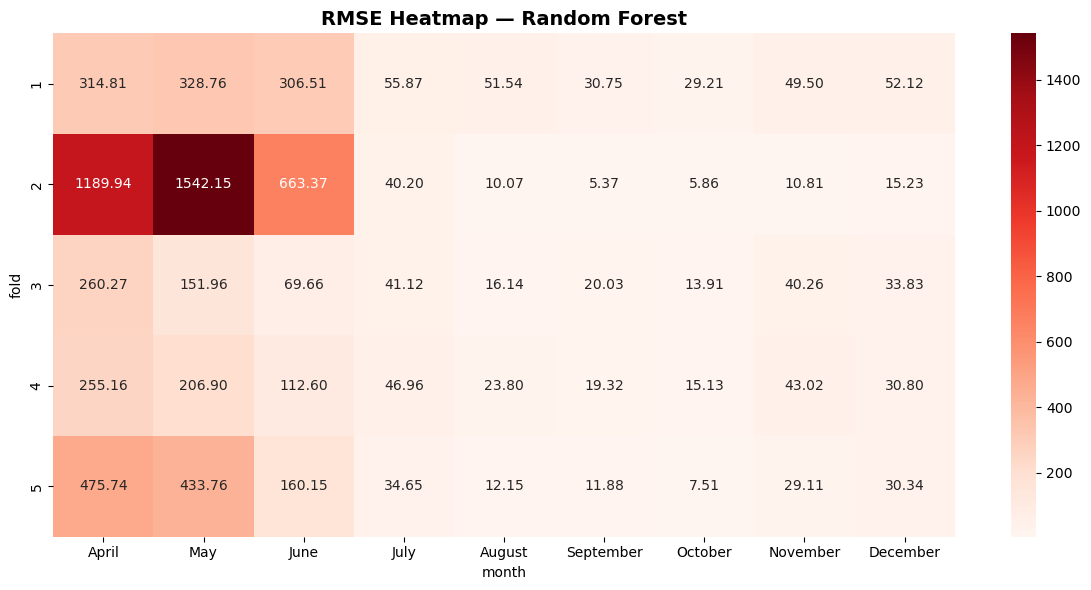

✓ Saved: /home/amolla/GIS_Spring26/GIS_521_FinalProject/RF_Dengue/rmse_heatmap.png


/tmp/ipykernel_2054275/1091610162.py:233: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_df.pivot_table(index="fold", columns="month", values=metric)


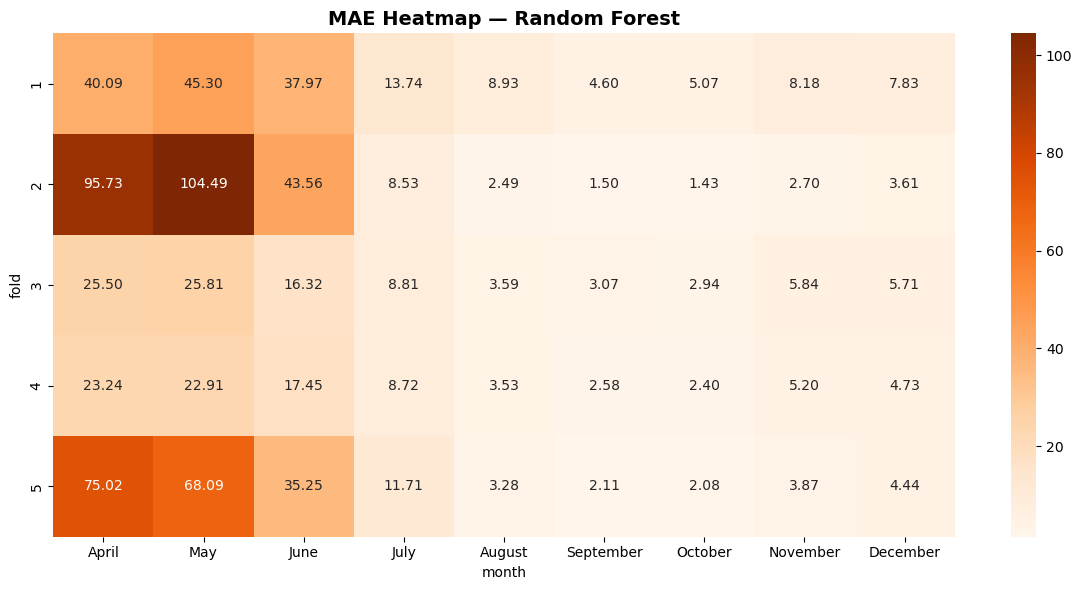

✓ Saved: /home/amolla/GIS_Spring26/GIS_521_FinalProject/RF_Dengue/mae_heatmap.png


/tmp/ipykernel_2054275/1091610162.py:233: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_df.pivot_table(index="fold", columns="month", values=metric)


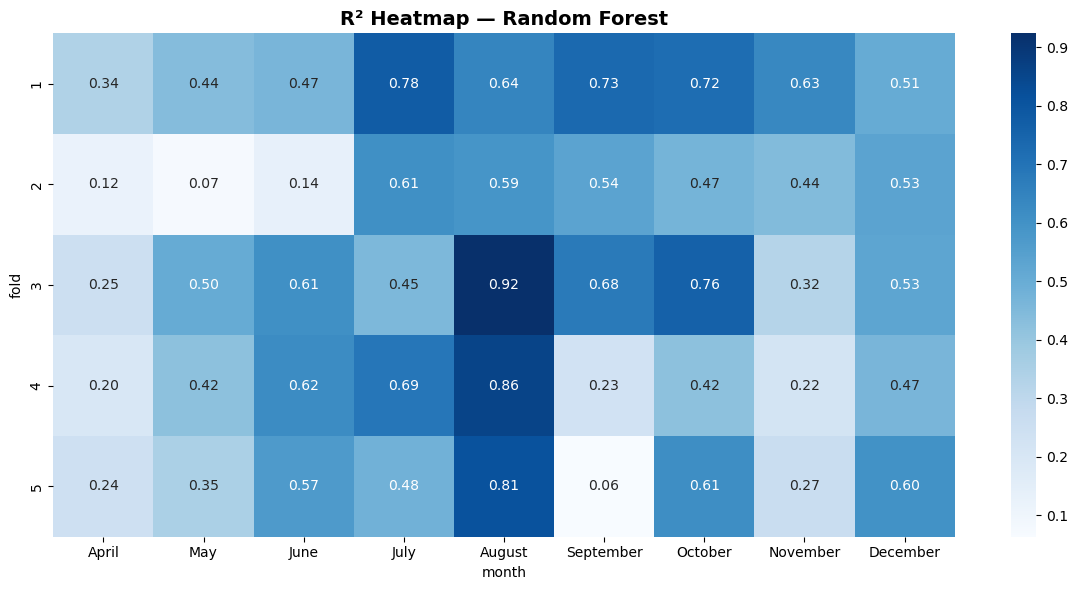

✓ Saved: /home/amolla/GIS_Spring26/GIS_521_FinalProject/RF_Dengue/r2_heatmap.png

--- TOP 10 FEATURES (Global Average Importance) ---
   1. log_dengue_lag1                     0.434106
   2. log_dengue_lag2                     0.186612
   3. population_density                  0.037667
   4. latitude                            0.034500
   5. builtup_fraction                    0.032082
   6. total_precipitation_lag1            0.030470
   7. near_coast_km                       0.027127
   8. total_precipitation_lag2            0.026653
   9. skin_temperature_lag2               0.025339
  10. temperature_2m_min_lag2             0.024664



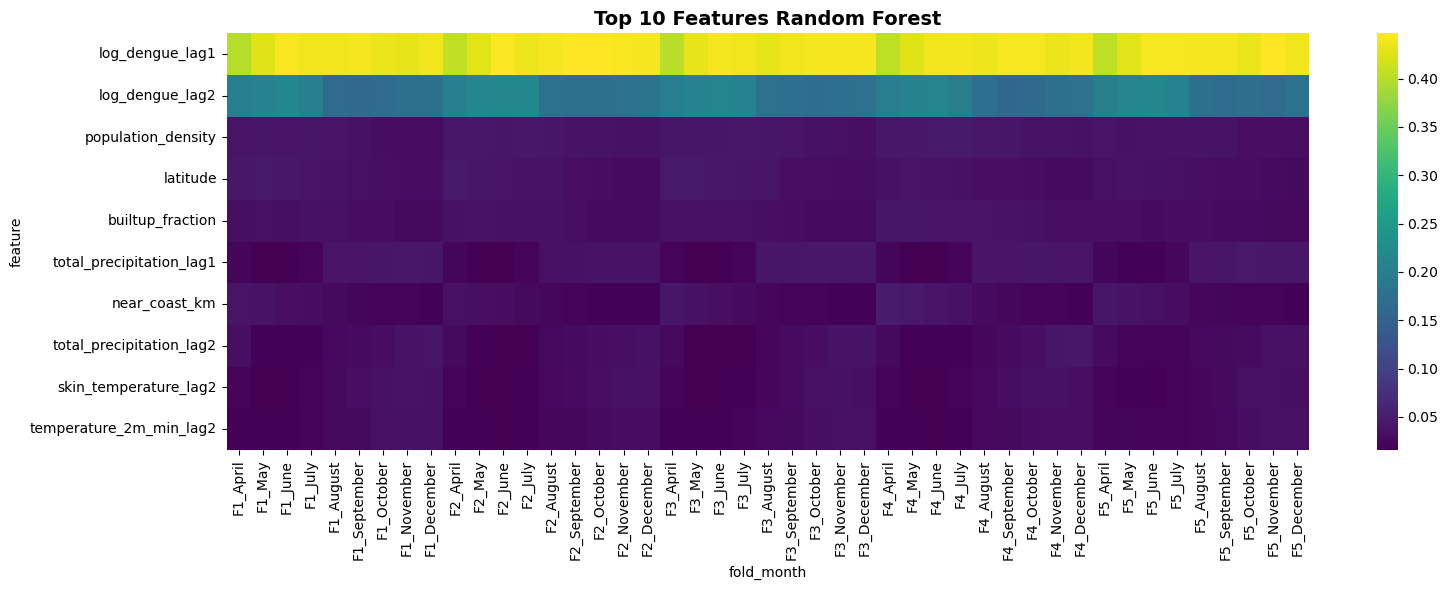

✓ Saved: /home/amolla/GIS_Spring26/GIS_521_FinalProject/RF_Dengue/feature_importance_heatmap.png

  MONTHLY AVERAGE PERFORMANCE
                 rmse        mae        r2
month                                     
April      499.183310  51.917494  0.231696
May        532.706605  53.319862  0.358699
June       262.456880  30.109214  0.479228
July        43.761417  10.301457  0.602178
August      22.739578   4.363600  0.765120
September   17.468821   2.773432  0.448752
October     14.324455   2.783627  0.597865
November    34.539773   5.158008  0.377395
December    32.465785   5.261745  0.526492

  FOLD AVERAGE PERFORMANCE
            rmse        mae        r2
fold                                 
1     135.452826  19.078443  0.583800
2     386.999216  29.337084  0.390848
3      71.908936  10.843197  0.559574
4      83.744359  10.085454  0.458572
5     132.809453  22.871622  0.444665


/tmp/ipykernel_2054275/1091610162.py:310: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(results_df.groupby("month")[["rmse", "mae", "r2"]].mean().to_string())


In [1]:
# Random Forest Main Model
# IMPORTS
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv("/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_panel_2019_FINAL.csv")

df.columns = df.columns.str.strip()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["Common_ID", "date"])

print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"  Date range  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Common_IDs  : {df['Common_ID'].nunique()} unique IDs  ({df['Common_ID'].min()} → {df['Common_ID'].max()})", flush=True)


# =========================================================
# TARGET TRANSFORM
# =========================================================
df["log_dengue"]      = np.log1p(df["dengue"])
df["log_dengue_lag1"] = np.log1p(df["dengue_lag1"])
df["log_dengue_lag2"] = np.log1p(df["dengue_lag2"])

print("\n✓ Log transforms applied (log_dengue, log_dengue_lag1, log_dengue_lag2)", flush=True)


# =========================================================
# FEATURES
# =========================================================
target = "log_dengue"

static_vars = [
    "near_coast_km", "elevation_meter",
    "population_density", "builtup_fraction",
    "latitude", "longitude"
]

monthly_vars = [
    "pdsi", "skin_temperature",
    "temperature_2m_max", "temperature_2m_min",
    "total_precipitation", "vs"
]

features = static_vars + [
    f"{v}_lag{l}" for v in monthly_vars for l in [1, 2]
] + ["log_dengue_lag1", "log_dengue_lag2"]

print(f"\n✓ Feature set: {len(features)} features")
print(f"  Static  : {static_vars}")
print(f"  Lagged  : {[f'{v}_lag{l}' for v in monthly_vars for l in [1,2]]}")
print(f"  Dengue  : ['log_dengue_lag1', 'log_dengue_lag2']", flush=True)


# =========================================================
# ORDERED SPATIAL FOLDS
# =========================================================
unique_ids = np.sort(df["Common_ID"].unique())
n_folds    = 5
fold_size  = len(unique_ids) // n_folds

folds = []

print(f"\n{'='*60}")
print(f"  SPATIAL FOLD SETUP — {n_folds} folds over {len(unique_ids)} unique IDs")
print(f"{'='*60}")

for i in range(n_folds):
    start = i * fold_size
    end   = len(unique_ids) if i == n_folds - 1 else (i + 1) * fold_size

    test_ids  = unique_ids[start:end]
    train_ids = np.setdiff1d(unique_ids, test_ids)

    folds.append((train_ids, test_ids))

    print(f"  Fold {i+1} → Test IDs : {test_ids.min()} → {test_ids.max()}  (n={len(test_ids)})  |  Train n={len(train_ids)}")

print(f"{'='*60}", flush=True)


# =========================================================
# MODEL PARAMETERS
# =========================================================
rf_params = {
    "n_estimators": 1000,
    "max_features": "sqrt",
    "n_jobs":       -1,
    "random_state": 42
}

print(f"\n✓ Random Forest params: {rf_params}", flush=True)


# =========================================================
# SAVE DIRECTORY
# =========================================================
save_dir = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/RF_Dengue"
os.makedirs(save_dir, exist_ok=True)
print(f"✓ Figures will be saved to: {save_dir}", flush=True)


# =========================================================
# STORAGE
# =========================================================
results    = []
fi_records = []


# =========================================================
# MAIN LOOP
# =========================================================
for fold_id, (train_ids, test_ids) in enumerate(folds, start=1):

    print(f"\n{'='*60}")
    print(f"  FOLD {fold_id} / {n_folds}")
    print(f"{'='*60}")
    print(f"  Train IDs : {train_ids.min()} → {train_ids.max()}  (n={len(train_ids)})")
    print(f"  Test  IDs : {test_ids.min()} → {test_ids.max()}  (n={len(test_ids)})")
    print(f"{'='*60}", flush=True)

    for month in range(4, 13):

        month_name = pd.to_datetime(f"2019-{month:02d}-01").strftime("%B")

        train_fold = df[
            (df["Common_ID"].isin(train_ids)) &
            (df["date"] < f"2019-{month:02d}-01")
        ]

        test_fold = df[
            (df["Common_ID"].isin(test_ids)) &
            (df["date"].dt.month == month)
        ]

        if train_fold.empty or test_fold.empty:
            print(f"  [{month_name}] ⚠ Skipped — train empty: {train_fold.empty}, test empty: {test_fold.empty}", flush=True)
            continue

        print(f"\n  [{month_name}]")
        print(f"    Train rows       : {len(train_fold)}  |  Test rows : {len(test_fold)}")
        print(f"    Train date range : {train_fold['date'].min().date()} → {train_fold['date'].max().date()}")
        print(f"    Test  date range : {test_fold['date'].min().date()} → {test_fold['date'].max().date()}")
        print(f"    Fitting model...", flush=True)

        model = RandomForestRegressor(**rf_params)
        model.fit(train_fold[features], train_fold[target])

        preds = model.predict(test_fold[features])

        y_true = np.expm1(test_fold[target])
        y_pred = np.expm1(preds)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)

        print(f"    ✓ RMSE: {rmse:.2f}  |  MAE: {mae:.2f}  |  R²: {r2:.4f}", flush=True)

        results.append({
            "fold":      fold_id,
            "month":     month_name,
            "month_num": month,
            "rmse":      rmse,
            "mae":       mae,
            "r2":        r2
        })

        # =====================================================
        # FEATURE IMPORTANCE (STORE RAW)
        # =====================================================
        importances = model.feature_importances_

        for f, imp in zip(features, importances):
            fi_records.append({
                "fold":      fold_id,
                "month":     month_name,
                "month_num": month,
                "feature":   f,
                "importance": imp
            })

print(f"\n{'='*60}")
print(f"  ✓ ALL FOLDS COMPLETE — {len(results)} fold-month results stored")
print(f"{'='*60}", flush=True)


# =========================================================
# DATAFRAMES
# =========================================================
results_df = pd.DataFrame(results)
fi_df      = pd.DataFrame(fi_records)

print(f"\n✓ results_df shape : {results_df.shape}")
print(f"✓ fi_df shape      : {fi_df.shape}", flush=True)


# =========================================================
# ORDER MONTHS
# =========================================================
month_order = [
    "April", "May", "June", "July",
    "August", "September", "October",
    "November", "December"
]

results_df["month"] = pd.Categorical(
    results_df["month"], categories=month_order, ordered=True
)

fi_df["month"] = pd.Categorical(
    fi_df["month"], categories=month_order, ordered=True
)


# =========================================================
# HEATMAP FUNCTION — SHOW + SAVE
# =========================================================
def plot_heatmap(metric, cmap, title):
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        results_df.pivot_table(index="fold", columns="month", values=metric)
        .reindex(columns=month_order),
        cmap=cmap,
        annot=True,
        fmt=".2f"
    )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    save_path = os.path.join(save_dir, f"{metric}_heatmap.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✓ Saved: {save_path}", flush=True)


print("\n--- PLOTTING HEATMAPS ---", flush=True)
plot_heatmap("rmse", "Reds",    "RMSE Heatmap — Random Forest")
plot_heatmap("mae",  "Oranges", "MAE Heatmap — Random Forest")
plot_heatmap("r2",   "Blues",   "R² Heatmap — Random Forest")


# =========================================================
# FEATURE IMPORTANCE — GLOBAL RANKING
# =========================================================
global_importance = (
    fi_df.groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
)

top_features = global_importance.index[:10]

print("\n--- TOP 10 FEATURES (Global Average Importance) ---")
for rank, (feat, imp) in enumerate(global_importance.head(10).items(), start=1):
    print(f"  {rank:2d}. {feat:<35s} {imp:.6f}")
print(flush=True)


# =========================================================
# FEATURE IMPORTANCE PIVOT
# =========================================================
fi_top = fi_df[fi_df["feature"].isin(top_features)].copy()

fi_top["fold_month"] = (
    "F" + fi_top["fold"].astype(str) + "_" + fi_top["month"].astype(str)
)

pivot_fi = fi_top.pivot_table(
    index="feature",
    columns="fold_month",
    values="importance",
    fill_value=0
)

ordered_cols = [f"F{f}_{m}" for f in range(1, 6) for m in month_order]
pivot_fi = pivot_fi.reindex(columns=ordered_cols)
pivot_fi = pivot_fi.reindex(index=top_features)


# =========================================================
# PLOT FEATURE IMPORTANCE — SHOW + SAVE
# =========================================================
plt.figure(figsize=(16, 6))
sns.heatmap(pivot_fi, cmap="viridis")
plt.title("Top 10 Features Random Forest", fontsize=14, fontweight="bold")
plt.tight_layout()
save_path = os.path.join(save_dir, "feature_importance_heatmap.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {save_path}", flush=True)


# =========================================================
# SUMMARY TABLES
# =========================================================
print("\n" + "="*60)
print("  MONTHLY AVERAGE PERFORMANCE")
print("="*60)
print(results_df.groupby("month")[["rmse", "mae", "r2"]].mean().to_string())

print("\n" + "="*60)
print("  FOLD AVERAGE PERFORMANCE")
print("="*60)
print(results_df.groupby("fold")[["rmse", "mae", "r2"]].mean().to_string())
print("="*60, flush=True)

✓ Data loaded: 556800 rows, 67 columns
  Date range  : 2019-03-01 → 2019-12-01
  Common_IDs  : 5568 unique IDs  (1 → 5571)

✓ Log transforms applied (log_dengue, log_dengue_lag1, log_dengue_lag2)

✓ Feature set: 20 features
  Static  : ['near_coast_km', 'elevation_meter', 'population_density', 'builtup_fraction', 'latitude', 'longitude']
  Lagged  : ['pdsi_lag1', 'pdsi_lag2', 'skin_temperature_lag1', 'skin_temperature_lag2', 'temperature_2m_max_lag1', 'temperature_2m_max_lag2', 'temperature_2m_min_lag1', 'temperature_2m_min_lag2', 'total_precipitation_lag1', 'total_precipitation_lag2', 'vs_lag1', 'vs_lag2']
  Dengue  : ['log_dengue_lag1', 'log_dengue_lag2']

  SPATIAL FOLD SETUP — 5 folds over 5568 unique IDs
  Fold 1 → Test IDs : 1 → 1115  (n=1113)  |  Train n=4455
  Fold 2 → Test IDs : 1116 → 2228  (n=1113)  |  Train n=4455
  Fold 3 → Test IDs : 2229 → 3342  (n=1113)  |  Train n=4455
  Fold 4 → Test IDs : 3343 → 4455  (n=1113)  |  Train n=4455
  Fold 5 → Test IDs : 4456 → 5571  (n=11

/tmp/ipykernel_2054275/1980051874.py:234: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_df.pivot_table(index="fold", columns="month", values=metric)


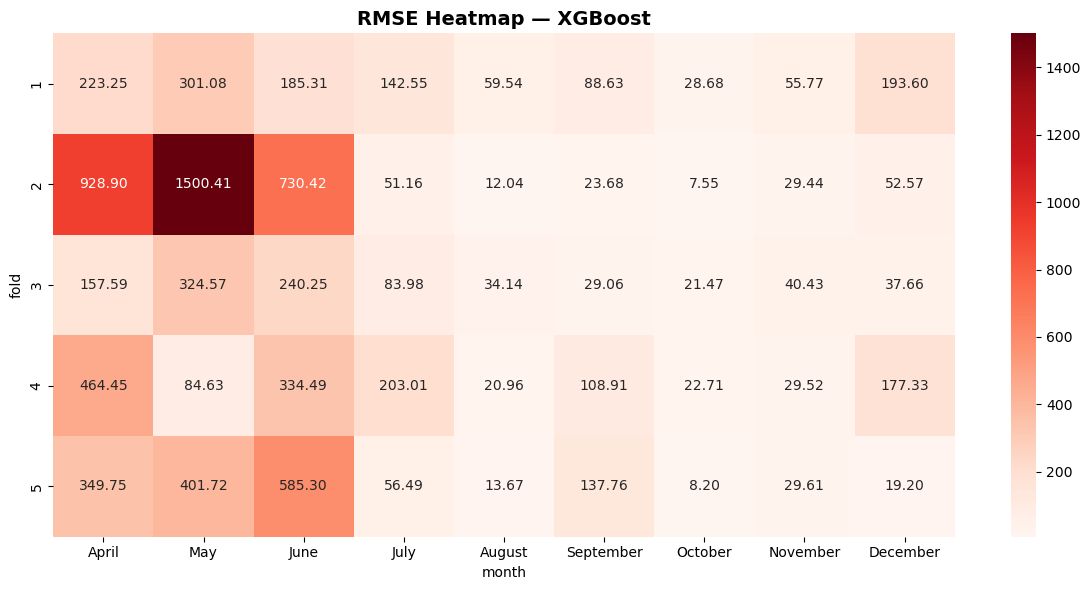

✓ Saved: /home/amolla/GIS_Spring26/GIS_521_FinalProject/XGB_Dengue/rmse_heatmap.png


/tmp/ipykernel_2054275/1980051874.py:234: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_df.pivot_table(index="fold", columns="month", values=metric)


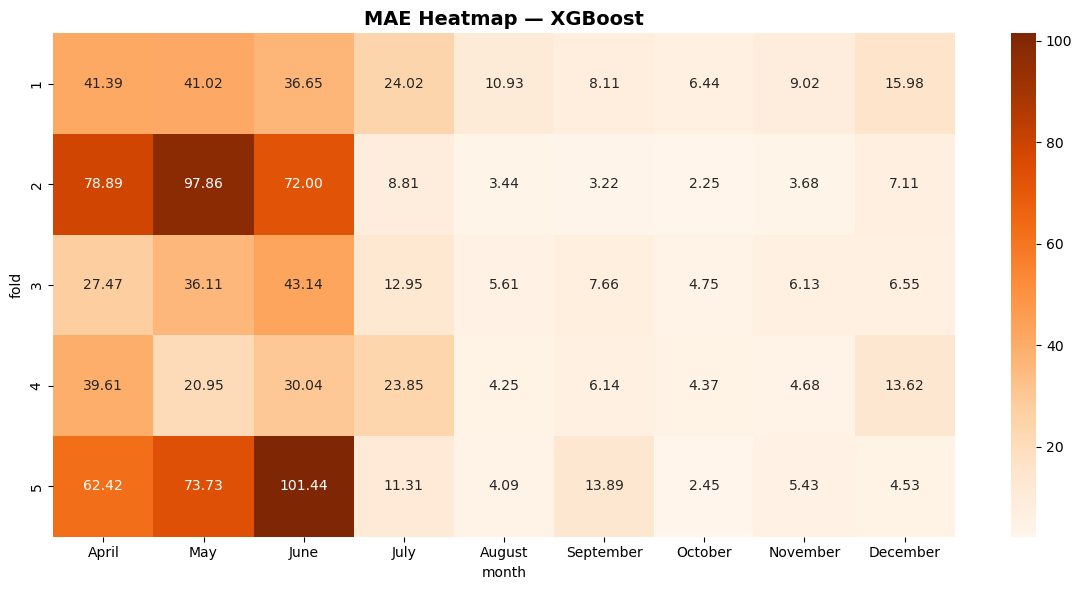

✓ Saved: /home/amolla/GIS_Spring26/GIS_521_FinalProject/XGB_Dengue/mae_heatmap.png


/tmp/ipykernel_2054275/1980051874.py:234: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_df.pivot_table(index="fold", columns="month", values=metric)


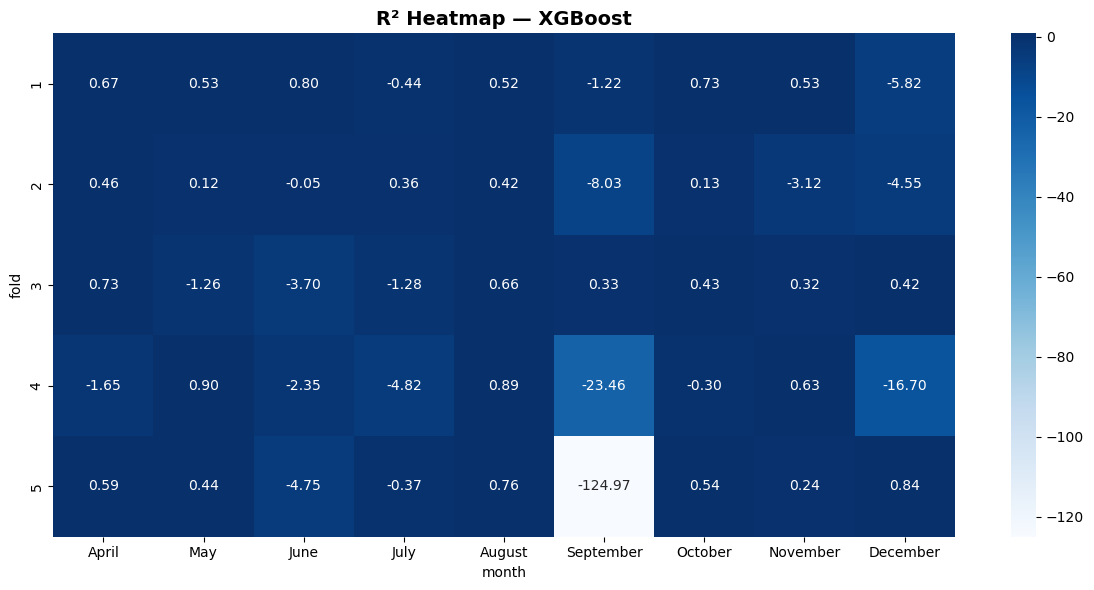

✓ Saved: /home/amolla/GIS_Spring26/GIS_521_FinalProject/XGB_Dengue/r2_heatmap.png

--- TOP 10 FEATURES (Global Average Importance) ---
   1. log_dengue_lag1                     0.802303
   2. total_precipitation_lag1            0.024849
   3. log_dengue_lag2                     0.021675
   4. latitude                            0.015350
   5. temperature_2m_max_lag2             0.015024
   6. longitude                           0.012757
   7. temperature_2m_min_lag2             0.011856
   8. total_precipitation_lag2            0.011682
   9. skin_temperature_lag1               0.011454
  10. builtup_fraction                    0.011158



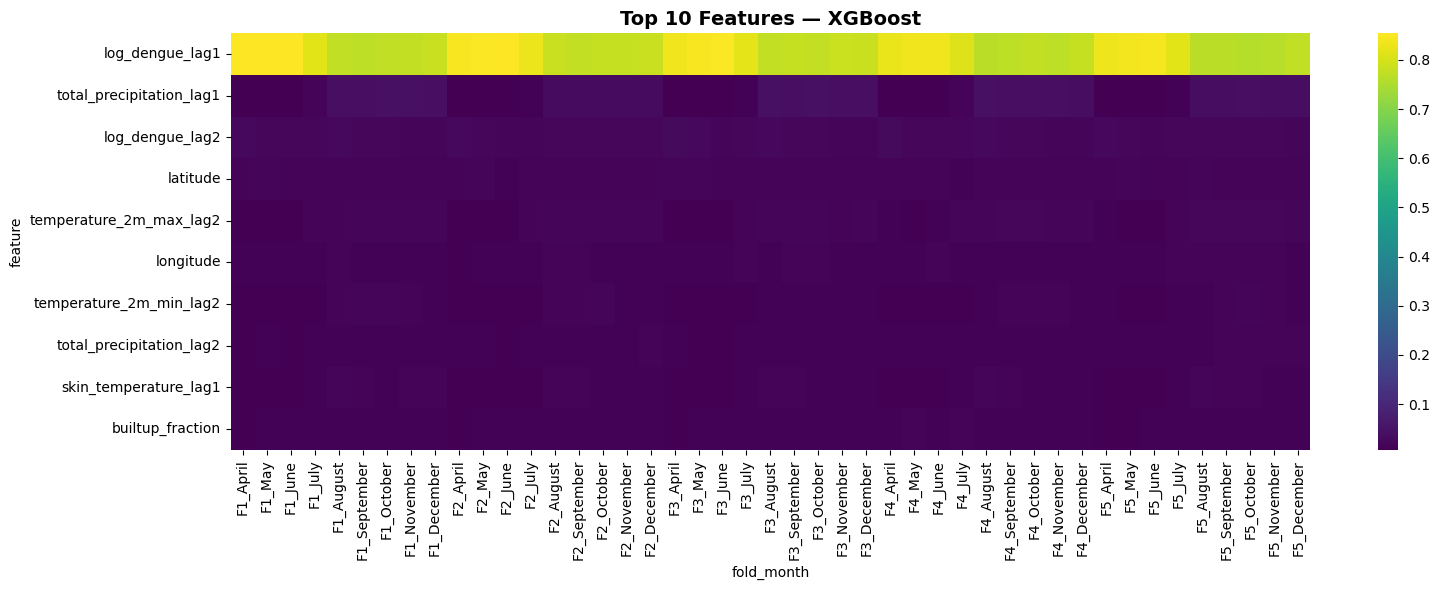

✓ Saved: /home/amolla/GIS_Spring26/GIS_521_FinalProject/XGB_Dengue/feature_importance_heatmap.png

  MONTHLY AVERAGE PERFORMANCE
                 rmse        mae         r2
month                                      
April      424.789918  49.955444   0.160154
May        522.481617  53.937353   0.147882
June       415.153231  56.653769  -2.008459
July       107.437303  16.187101  -1.309575
August      28.068565   5.665929   0.649402
September   77.608482   7.803750 -31.471248
October     17.724321   4.051877   0.304449
November    36.954703   5.788215  -0.279408
December    96.071638   9.559109  -5.164278

  FOLD AVERAGE PERFORMANCE
            rmse        mae         r2
fold                                  
1     142.045456  21.507706  -0.410982
2     370.684030  30.806101  -1.584794
3     107.682719  16.708752  -0.373513
4     160.669468  16.390382  -5.206340
5     177.968203  31.032919 -14.074971


/tmp/ipykernel_2054275/1980051874.py:314: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(results_df.groupby("month")[["rmse", "mae", "r2"]].mean().to_string())


In [3]:
# XGBoost Competitor Model Performance

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv("/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_panel_2019_FINAL.csv")

df.columns = df.columns.str.strip()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["Common_ID", "date"])

print(f"✓ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"  Date range  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"  Common_IDs  : {df['Common_ID'].nunique()} unique IDs  ({df['Common_ID'].min()} → {df['Common_ID'].max()})", flush=True)


# =========================================================
# TARGET TRANSFORM
# =========================================================
df["log_dengue"]      = np.log1p(df["dengue"])
df["log_dengue_lag1"] = np.log1p(df["dengue_lag1"])
df["log_dengue_lag2"] = np.log1p(df["dengue_lag2"])

print("\n✓ Log transforms applied (log_dengue, log_dengue_lag1, log_dengue_lag2)", flush=True)


# =========================================================
# FEATURES
# =========================================================
target = "log_dengue"

static_vars = [
    "near_coast_km", "elevation_meter",
    "population_density", "builtup_fraction",
    "latitude", "longitude"
]

monthly_vars = [
    "pdsi", "skin_temperature",
    "temperature_2m_max", "temperature_2m_min",
    "total_precipitation", "vs"
]

features = static_vars + [
    f"{v}_lag{l}" for v in monthly_vars for l in [1, 2]
] + ["log_dengue_lag1", "log_dengue_lag2"]

print(f"\n✓ Feature set: {len(features)} features")
print(f"  Static  : {static_vars}")
print(f"  Lagged  : {[f'{v}_lag{l}' for v in monthly_vars for l in [1,2]]}")
print(f"  Dengue  : ['log_dengue_lag1', 'log_dengue_lag2']", flush=True)


# =========================================================
# SPATIAL FOLDS
# =========================================================
unique_ids = np.sort(df["Common_ID"].unique())
n_folds    = 5
fold_size  = len(unique_ids) // n_folds

folds = []

print(f"\n{'='*60}")
print(f"  SPATIAL FOLD SETUP — {n_folds} folds over {len(unique_ids)} unique IDs")
print(f"{'='*60}")

for i in range(n_folds):
    start = i * fold_size
    end   = len(unique_ids) if i == n_folds - 1 else (i + 1) * fold_size

    test_ids  = unique_ids[start:end]
    train_ids = np.setdiff1d(unique_ids, test_ids)

    folds.append((train_ids, test_ids))

    print(f"  Fold {i+1} → Test IDs : {test_ids.min()} → {test_ids.max()}  (n={len(test_ids)})  |  Train n={len(train_ids)}")

print(f"{'='*60}", flush=True)


# =========================================================
# MODEL
# =========================================================
xgb_params = {
    "n_estimators": 1000,
    "random_state": 42,
    "n_jobs": -1
}

print(f"\n✓ XGBoost params: {xgb_params}", flush=True)


# =========================================================
# SAVE DIRECTORY
# =========================================================
save_dir = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/XGB_Dengue"
os.makedirs(save_dir, exist_ok=True)
print(f"✓ Figures will be saved to: {save_dir}", flush=True)


# =========================================================
# STORAGE
# =========================================================
results    = []
fi_records = []


# =========================================================
# MAIN LOOP
# =========================================================
for fold_id, (train_ids, test_ids) in enumerate(folds, start=1):

    print(f"\n{'='*60}")
    print(f"  FOLD {fold_id} / {n_folds}")
    print(f"{'='*60}")
    print(f"  Train IDs : {train_ids.min()} → {train_ids.max()}  (n={len(train_ids)})")
    print(f"  Test  IDs : {test_ids.min()} → {test_ids.max()}  (n={len(test_ids)})")
    print(f"{'='*60}", flush=True)

    for month in range(4, 13):

        month_name = pd.to_datetime(f"2019-{month:02d}-01").strftime("%B")

        train_fold = df[
            (df["Common_ID"].isin(train_ids)) &
            (df["date"] < f"2019-{month:02d}-01")
        ]

        test_fold = df[
            (df["Common_ID"].isin(test_ids)) &
            (df["date"].dt.month == month)
        ]

        if train_fold.empty or test_fold.empty:
            print(f"  [{month_name}] ⚠ Skipped — train empty: {train_fold.empty}, test empty: {test_fold.empty}", flush=True)
            continue

        print(f"\n  [{month_name}]")
        print(f"    Train rows       : {len(train_fold)}  |  Test rows : {len(test_fold)}")
        print(f"    Train date range : {train_fold['date'].min().date()} → {train_fold['date'].max().date()}")
        print(f"    Test  date range : {test_fold['date'].min().date()} → {test_fold['date'].max().date()}")
        print(f"    Fitting model...", flush=True)

        model = XGBRegressor(**xgb_params)
        model.fit(train_fold[features], train_fold[target], verbose=False)

        preds = model.predict(test_fold[features])

        y_true = np.expm1(test_fold[target])
        y_pred = np.expm1(preds)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)

        print(f"    ✓ RMSE: {rmse:.2f}  |  MAE: {mae:.2f}  |  R²: {r2:.4f}", flush=True)

        results.append({
            "fold": fold_id,
            "month": month_name,
            "month_num": month,
            "rmse": rmse,
            "mae": mae,
            "r2": r2
        })

        # =====================================================
        # FEATURE IMPORTANCE
        # =====================================================
        importances = model.feature_importances_

        for f, imp in zip(features, importances):
            fi_records.append({
                "fold": fold_id,
                "month": month_name,
                "month_num": month,
                "feature": f,
                "importance": imp
            })


# =========================================================
# FINAL
# =========================================================
print(f"\n{'='*60}")
print(f"  ✓ ALL FOLDS COMPLETE — {len(results)} fold-month results stored")
print(f"{'='*60}", flush=True)


# =========================================================
# DATAFRAMES
# =========================================================
results_df = pd.DataFrame(results)
fi_df      = pd.DataFrame(fi_records)

print(f"\n✓ results_df shape : {results_df.shape}")
print(f"✓ fi_df shape      : {fi_df.shape}", flush=True)


# =========================================================
# MONTH ORDER
# =========================================================
month_order = [
    "April","May","June","July",
    "August","September","October",
    "November","December"
]

results_df["month"] = pd.Categorical(results_df["month"], categories=month_order, ordered=True)
fi_df["month"] = pd.Categorical(fi_df["month"], categories=month_order, ordered=True)


# =========================================================
# HEATMAP FUNCTION
# =========================================================
def plot_heatmap(metric, cmap, title):

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        results_df.pivot_table(index="fold", columns="month", values=metric)
        .reindex(columns=month_order),
        cmap=cmap,
        annot=True,
        fmt=".2f"
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()

    save_path = os.path.join(save_dir, f"{metric}_heatmap.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"✓ Saved: {save_path}", flush=True)


# =========================================================
# PLOTS
# =========================================================
print("\n--- PLOTTING HEATMAPS ---", flush=True)

plot_heatmap("rmse", "Reds",    "RMSE Heatmap — XGBoost")
plot_heatmap("mae",  "Oranges", "MAE Heatmap — XGBoost")
plot_heatmap("r2",   "Blues",   "R² Heatmap — XGBoost")


# =========================================================
# FEATURE IMPORTANCE — GLOBAL RANKING (RF-MATCHED)
# =========================================================
global_importance = (
    fi_df.groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
)

top_features = global_importance.index[:10]

print("\n--- TOP 10 FEATURES (Global Average Importance) ---")
for rank, (feat, imp) in enumerate(global_importance.head(10).items(), start=1):
    print(f"  {rank:2d}. {feat:<35s} {imp:.6f}")
print(flush=True)


# =========================================================
# FEATURE IMPORTANCE PIVOT + PLOT
# =========================================================
fi_top = fi_df[fi_df["feature"].isin(top_features)].copy()

fi_top["fold_month"] = "F" + fi_top["fold"].astype(str) + "_" + fi_top["month"].astype(str)

pivot_fi = fi_top.pivot_table(
    index="feature",
    columns="fold_month",
    values="importance",
    fill_value=0
)

ordered_cols = [f"F{f}_{m}" for f in range(1, 6) for m in month_order]
pivot_fi = pivot_fi.reindex(columns=ordered_cols)
pivot_fi = pivot_fi.reindex(index=top_features)

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_fi, cmap="viridis")
plt.title("Top 10 Features — XGBoost", fontsize=14, fontweight="bold")
plt.tight_layout()

save_path = os.path.join(save_dir, "feature_importance_heatmap.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Saved: {save_path}", flush=True)


# =========================================================
# SUMMARY TABLES
# =========================================================
print("\n" + "="*60)
print("  MONTHLY AVERAGE PERFORMANCE")
print("="*60)
print(results_df.groupby("month")[["rmse", "mae", "r2"]].mean().to_string())

print("\n" + "="*60)
print("  FOLD AVERAGE PERFORMANCE")
print("="*60)
print(results_df.groupby("fold")[["rmse", "mae", "r2"]].mean().to_string())
print("="*60, flush=True)

In [26]:
## Hot Spot Network Analysis

# Load Dengue Data

file_path = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_dengue_HotSpot95Confd.csv"
df = pd.read_csv(file_path)

lat_col = "latitude"
lon_col = "longitude"

monthly_cols = [
    "den_2019_01","den_2019_02","den_2019_03","den_2019_04",
    "den_2019_05","den_2019_06","den_2019_07","den_2019_08",
    "den_2019_09","den_2019_10","den_2019_11","den_2019_12"
]

df[monthly_cols] = df[monthly_cols].fillna(0)
df["den_2019_total"] = df[monthly_cols].sum(axis=1)
weights = df["den_2019_total"].values


# Weighted Gravitational Centroid

centroid_lat = np.sum(df[lat_col] * weights) / np.sum(weights)
centroid_lon = np.sum(df[lon_col] * weights) / np.sum(weights)

print("Weighted Gravitational Centroid (2019 dengue):")
print("Latitude:", centroid_lat)
print("Longitude:", centroid_lon)


# Haversine Distance Function

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c


# Build 500 km Network

threshold_km = 500
G = nx.Graph()
n = len(df)

for i in range(n):
    G.add_node(i)

for i in range(n):
    for j in range(i+1, n):
        dist_ij = haversine(df.loc[i, lat_col], df.loc[i, lon_col],
                            df.loc[j, lat_col], df.loc[j, lon_col])
        if dist_ij <= threshold_km:
            G.add_edge(i, j)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges (≤500 km):", G.number_of_edges())


# Create Base Map

m = folium.Map(
    location=[df[lat_col].mean(), df[lon_col].mean()],
    zoom_start=5,
    tiles="CartoDB Positron"
)


# Draw Network Edges

edge_layer = folium.FeatureGroup(name="500km Network")

for edge in G.edges():
    lat1 = df.loc[edge[0], lat_col]
    lon1 = df.loc[edge[0], lon_col]
    lat2 = df.loc[edge[1], lat_col]
    lon2 = df.loc[edge[1], lon_col]

    folium.PolyLine(
        locations=[(lat1, lon1), (lat2, lon2)],
        weight=1,
        color="blue",
        opacity=0.5
    ).add_to(edge_layer)

edge_layer.add_to(m)


# Draw Municipality Nodes

node_layer = folium.FeatureGroup(name="Municipalities")

max_weight = df["den_2019_total"].max()

for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row[lat_col], row[lon_col]],
        radius=3 + (row["den_2019_total"] / max_weight) * 8,
        fill=False,
        color="red",
        weight=2,
        popup=f"Total 2019 Dengue: {row['den_2019_total']}"
    ).add_to(node_layer)

node_layer.add_to(m)


# Add Gravitational Centroid

centroid_layer = folium.FeatureGroup(name="Gravitational Centroid")

folium.Marker(
    location=[centroid_lat, centroid_lon],
    popup="Weighted Gravitational Centroid (2019)",
    icon=folium.Icon(color="green", icon="star")
).add_to(centroid_layer)

centroid_layer.add_to(m)


# Load and Add Airports

airport_csv = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/Brazil_Airport.csv"
airport_df = pd.read_csv(airport_csv, encoding="latin1")

airport_df["Location"] = airport_df["Location"].str.strip()
airport_df[["lat", "lon"]] = airport_df["Location"].str.split(",", expand=True)

airport_df["lat"] = airport_df["lat"].astype(float)
airport_df["lon"] = airport_df["lon"].astype(float)

airport_layer = folium.FeatureGroup(name="Airports")

for _, row in airport_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color="black",
        fill=True,
        fill_color="yellow",
        fill_opacity=0.9,
        popup=f"Airport: {row['Airport']}"
    ).add_to(airport_layer)

airport_layer.add_to(m)


# Add Layer Control

folium.LayerControl(collapsed=False).add_to(m)


# Save Map

output_path = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_weighted_network_500km_with_airports.html"
m.save(output_path)

print("Map saved to:", output_path)


Weighted Gravitational Centroid (2019 dengue):
Latitude: -17.968080988133536
Longitude: -45.038928795916725
Number of nodes: 23
Number of edges (≤500 km): 75
Map saved to: /home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_weighted_network_500km_with_airports.html


Data shape: (556800, 67)

=== Correlation of Predictors with Target ===
log_dengue                  1.000000
log_dengue_lag1             0.975783
log_dengue_lag2             0.951556
temperature_2m_min_lag2     0.200248
builtup_fraction            0.189165
population_density          0.175287
total_precipitation_lag2    0.154619
skin_temperature_lag2       0.148113
temperature_2m_min_lag1     0.127389
total_precipitation_lag1    0.122141
temperature_2m_max_lag2     0.090272
skin_temperature_lag1       0.053009
vs_lag2                     0.037696
near_coast_km               0.035279
longitude                   0.031352
vs_lag1                     0.030328
elevation_meter             0.013718
latitude                   -0.005305
temperature_2m_max_lag1    -0.047259
pdsi_lag1                  -0.081043
pdsi_lag2                  -0.084794
Name: log_dengue, dtype: float64


/tmp/ipykernel_2054275/697942143.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


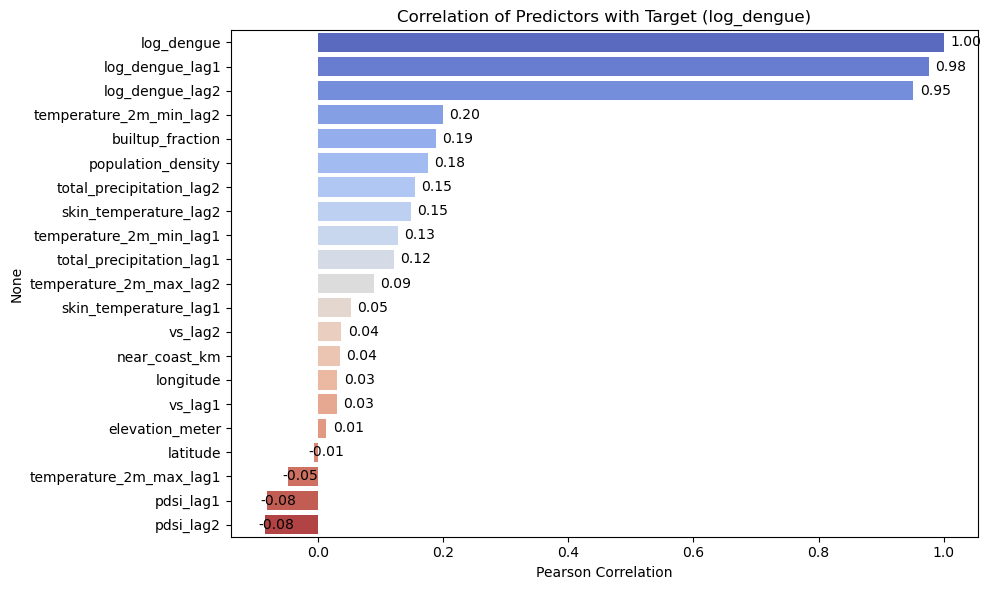

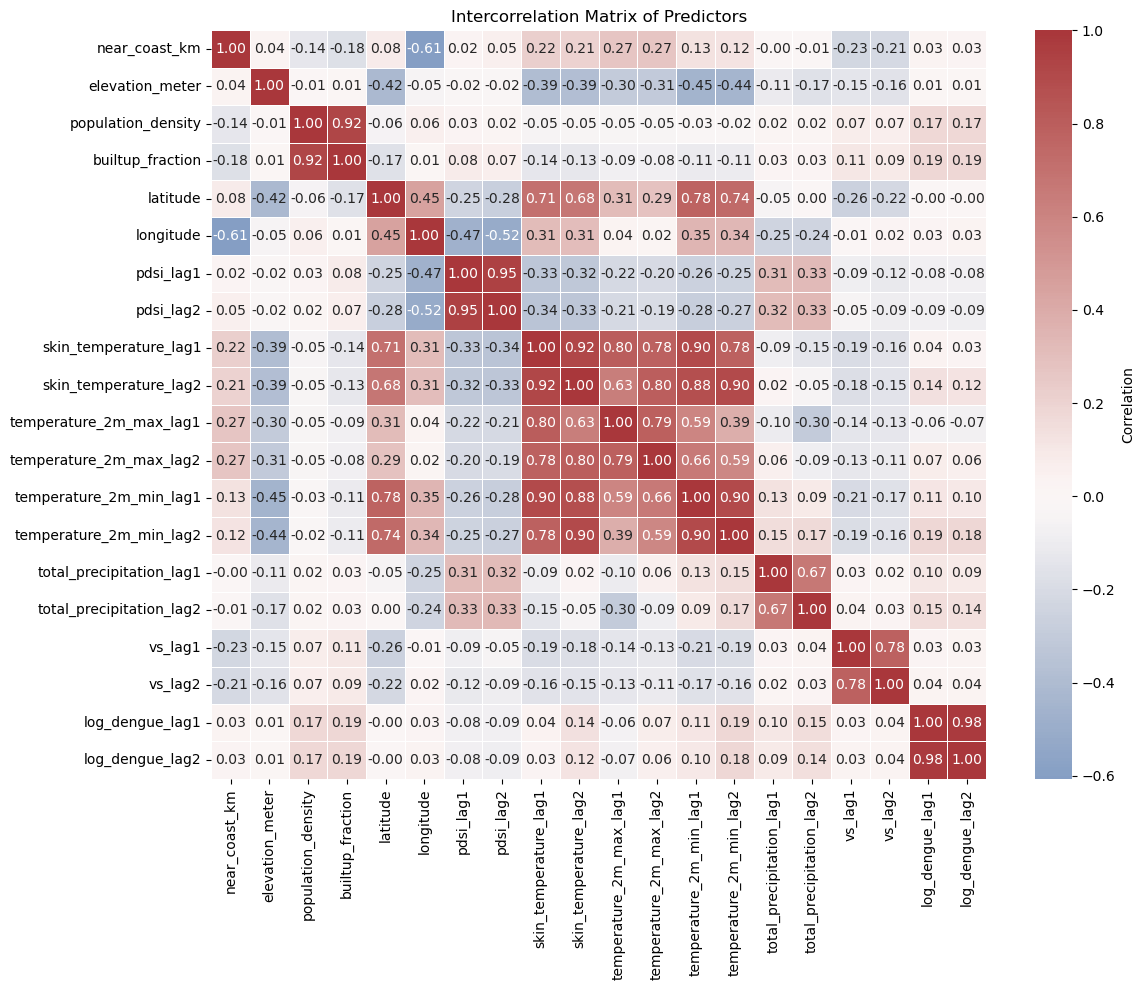

In [2]:
# Correlation Analysis with Values Shown

# Load dataset

csv_path = "/home/amolla/GIS_Spring26/GIS_521_FinalProject/brazil_panel_2019_FINAL.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
df["date"] = pd.to_datetime(df["date"])

print("Data shape:", df.shape)


# Create log-transformed dengue & lag variables

if "dengue" not in df.columns:
    raise ValueError("Your CSV must contain a 'dengue' column")

df["log_dengue"] = np.log1p(df["dengue"])

if "Common_ID" not in df.columns:
    df["Common_ID"] = df.index  # fallback if no municipality ID

df = df.sort_values(["Common_ID", "date"])

df["log_dengue_lag1"] = df.groupby("Common_ID")["log_dengue"].shift(1)
df["log_dengue_lag2"] = df.groupby("Common_ID")["log_dengue"].shift(2)
df[["log_dengue_lag1", "log_dengue_lag2"]] = df[["log_dengue_lag1", "log_dengue_lag2"]].fillna(0)


# Define features

target = "log_dengue"

static_vars = [
    "near_coast_km", "elevation_meter",
    "population_density", "builtup_fraction",
    "latitude", "longitude"
]

monthly_vars = [
    "pdsi",
    "skin_temperature",
    "temperature_2m_max", "temperature_2m_min",
    "total_precipitation", "vs"
]

climate_lags = [
    f"{var}_lag{lag}"
    for var in monthly_vars
    for lag in range(1,3)
]

lagged_dengue = ["log_dengue_lag1", "log_dengue_lag2"]

features = static_vars + climate_lags + lagged_dengue


# Correlation of predictors with target

corr_with_target = df[features + [target]].corr()[target].sort_values(ascending=False)

print("\n=== Correlation of Predictors with Target ===")
print(corr_with_target)

# Plot predictor-target correlations with exact values
plt.figure(figsize=(10,6))
bars = sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    palette="coolwarm"
)

# Add correlation values to bars
for bar in bars.patches:
    width = bar.get_width()
    plt.text(width + 0.01*np.sign(width), bar.get_y() + bar.get_height()/2,
             f'{width:.2f}', va='center', fontsize=10)

plt.title("Correlation of Predictors with Target (log_dengue)")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()



# Intercorrelation among predictors

predictor_corr = df[features].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    predictor_corr, 
    cmap="vlag", 
    center=0, 
    annot=True,       # show values
    fmt=".2f",        # two decimal places
    cbar_kws={'label': 'Correlation'},
    linewidths=0.5
)
plt.title("Intercorrelation Matrix of Predictors")
plt.tight_layout()
plt.show()